In [1]:
import pandas as pd
import warnings

In [2]:


warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
df = pd.read_csv('./data/twitter_training.csv')

In [4]:
val_df = pd.read_csv('./data/twitter_validation.csv')

In [7]:
df['tweet_content'].values

array(['I am coming to the borders and I will kill you all,',
       'im getting on borderlands and i will kill you all,',
       'im coming on borderlands and i will murder you all,', ...,
       'Just realized the windows partition of my Mac is now 6 years behind on Nvidia drivers and I have no idea how he didn’t notice',
       'Just realized between the windows partition of my Mac is like being 6 years behind on Nvidia drivers and cars I have no fucking idea how I ever didn ’ t notice',
       'Just like the windows partition of my Mac is like 6 years behind on its drivers So you have no idea how I didn’t notice'],
      shape=(73990,), dtype=object)

In [8]:
print(df.duplicated().sum())


2339


In [5]:
df1 = df.copy()

In [6]:
# %pip install spacy

import spacy
# Download the model if not already present
import subprocess
try:
	nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])
except OSError:
	subprocess.run(["python", "-m", "spacy", "download", "en_core_web_lg"])
	nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])

In [11]:
df1['tweet_content'].sample(5).values

array(['I CAN NOT WAIT FOR THISSSSS',
       'Playing and streaming Hearthstone again honestly fucking amazing!. When I stopped, it threw my streams into the mud, and it seems like that was the only thing that could actually get me out of it too.',
       '@Rainbow6Game just won in a ranked second placement and wifi dropped through in the last round of getting a flawless set victory??? Anything that you can do??',
       'HearthStone @OSCesports Championship Rankings is updated with last week results. With 4 victories last past weekend at 5 tourneys @MadDoom5.  keeps increasing his advantage in OSC Points and now with 7 tournaments victories. oscesports.com/hearthstone-ra….. @HSesports @HSReplayNet',
       'Never shoot me in the back and miss... store.playstation.com /'],
      dtype=object)

In [7]:
import contractions
import re
import emoji
from bs4 import BeautifulSoup

def preprocess_text(text):
    # Converts emoji to text
    text = emoji.demojize(text)
    text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags
    
    text = contractions.fix(text)  # Expand contractions
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Reduce repeated characters
    text=re.sub(r"[@#^<>|(){}[\]\~*+=]", " ", text) # Remove less important special characters
    text=re.sub(r"\s+", " ", text)
    text = text.strip()  # Remove leading and trailing spaces
    return text

In [8]:
df1['tweet_content'] = df1['tweet_content'].apply(lambda x: preprocess_text(x))
val_df['tweet_content'] = val_df['tweet_content'].apply(lambda x: preprocess_text(x))

### Now, let's create a function to check if any of the rows contain only spaces or punctuations

In [9]:
def check_for_only_spaces_or_punctuations(text):
    # Check if the text contains only spaces or punctuation
    if not text or text.isspace() or re.match(r'^[\W_]+$', text):
        return True
    
    doc = nlp(text)
    
    if all (token.is_punct or token.is_space for token in doc):
        return True
    
    return False

In [10]:
df1['status'] = df1['tweet_content'].apply(check_for_only_spaces_or_punctuations)

In [11]:
df1.drop(df1[df1['status'] == True].index, inplace=True)

In [12]:
df1['text_length'] = df1['tweet_content'].apply(lambda x: len(x.split()))

In [13]:
df1.groupby('sentiment')['text_length'].describe().T

sentiment,Irrelevant,Negative,Neutral,Positive
count,12803.000000,22238.000000,17972.000000,20540.000000
mean,19.925642,20.346569,20.370743,17.467235
std,14.370674,15.032366,14.020976,14.157219
min,1.000000,1.000000,1.000000,1.000000
25%,9.000000,8.000000,10.000000,7.000000
50%,16.000000,16.000000,17.000000,14.000000
75%,28.000000,29.000000,28.000000,24.000000
max,163.000000,189.000000,194.000000,167.000000


In [14]:
df1.head()

,ID,entity,sentiment,tweet_content,status,text_length
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,False,12
1,2401,Borderlands,Positive,i am getting on borderlands and i will kill yo...,False,11
2,2401,Borderlands,Positive,i am coming on borderlands and i will murder y...,False,11
3,2401,Borderlands,Positive,i am getting on borderlands 2 and i will murde...,False,13
4,2401,Borderlands,Positive,i am getting into borderlands and i can murder...,False,11


In [15]:
df1.drop(columns=['status','ID','text_length'], inplace=True)

In [16]:
df1.drop_duplicates(inplace=True)

In [17]:
df1.reset_index(drop=True, inplace=True)

In [18]:
val_df.drop(columns=['ID'], inplace=True)

In [19]:
df = df1.copy()

In [20]:
df.head()

,entity,sentiment,tweet_content
0,Borderlands,Positive,i am coming to the borders and i will kill you...
1,Borderlands,Positive,i am getting on borderlands and i will kill yo...
2,Borderlands,Positive,i am coming on borderlands and i will murder y...
3,Borderlands,Positive,i am getting on borderlands 2 and i will murde...
4,Borderlands,Positive,i am getting into borderlands and i can murder...


In [26]:
def remove_stopword(text):
    doc = nlp(text)
    filtered_tokens = [token.text for token in doc if not token.is_stop]
    return " ".join(filtered_tokens)

In [34]:
df['stopword_text'] =df['tweet_content'].apply(remove_stopword)



In [21]:
def lemmatize_texts(texts, data):
    data[texts] = data[texts].astype(str)
    lemmatized = [
        " ".join(token.lemma_ for token in doc)
        for doc in nlp.pipe(data[texts], batch_size=256, n_process=-1)
    ]
    return pd.Series(lemmatized, index=data.index)




In [22]:
df['lemmatized_text']  = lemmatize_texts('tweet_content', df)

In [23]:
val_df['lemmatized_text']  = lemmatize_texts('tweet_content', val_df)

In [24]:
def tokenize(text):
    tokens = []
    for token in nlp(text.lower()):
        tokens.append(token.text)
    return tokens

In [25]:
df['tokenized_text'] = df['lemmatized_text'].apply(tokenize)

In [26]:
val_df['tokenized_text'] = val_df['lemmatized_text'].apply(tokenize)

In [157]:
df['lemmatized_text']

0        I be come to the border and I will kill you all ,
1         I be get on borderland and I will kill you all ,
2        I be come on borderland and I will murder you ...
3        I be get on borderland 2 and I will murder you...
4        I be get into borderland and I can murder you ...
                               ...                        
69377    just realize that the window partition of my m...
69378    just realize that my mac window partition be 6...
69379    just realize the window partition of my mac be...
69380    just realize between the window partition of m...
69381    just like the window partition of my mac be li...
Name: lemmatized_text, Length: 69382, dtype: object

In [80]:
df['tokenized_text']

0        [i, be, come, to, the, border, and, i, will, k...
1        [i, be, get, on, borderland, and, i, will, kil...
2        [i, be, come, on, borderland, and, i, will, mu...
3        [i, be, get, on, borderland, 2, and, i, will, ...
4        [i, be, get, into, borderland, and, i, can, mu...
                               ...                        
69377    [just, realize, that, the, window, partition, ...
69378    [just, realize, that, my, mac, window, partiti...
69379    [just, realize, the, window, partition, of, my...
69380    [just, realize, between, the, window, partitio...
69381    [just, like, the, window, partition, of, my, m...
Name: tokenized_text, Length: 69382, dtype: object

In [81]:
from collections import Counter

def word_occurrence(df):
    sentences = []
    for _ , row in df.iterrows():
        text = row['tokenized_text']   
       
        sentences.extend(text)
    
    vocab = {'<unk>': 0}
    
    for token in Counter(sentences):
        if token not in vocab:
            vocab[token] = len(vocab)
    
    return vocab
    
        

In [82]:
vocab = word_occurrence(df)

In [83]:
len(vocab)

33030

In [84]:
import json
with open('./data/vocab.json', 'w') as f:
    json.dump(vocab, f)

In [85]:
def replace_word_with_numbers(text):
    tokens = []
    for token in text:
        if token in vocab:
            tokens.append(vocab[token])
        else:
            tokens.append(vocab['<unk>'])
    return tokens

In [159]:
df['tokenized_text_in_numbers'] = df['tokenized_text'].apply(replace_word_with_numbers)

In [160]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text'].apply(replace_word_with_numbers)

In [162]:
def padding(text):
    max_len = 200
    if len(text) > max_len:
        max_len = len(text)
    return text + [0] * (max_len - len(text))

In [89]:
df['tokenized_text_in_numbers'] = df['tokenized_text_in_numbers'].apply(padding)

In [164]:
pad1 = df['tokenized_text_in_numbers'].apply(padding)

In [165]:
def padding(text, max_len=200):
    return text[:max_len] + [0] * (max_len - len(text))


In [166]:
pad2 = df['tokenized_text_in_numbers'].apply(padding)

In [34]:
df['tokenized_text_in_numbers'].head()

0    [1, 2, 3, 4, 5, 6, 7, 1, 8, 9, 10, 11, 12, 0, ...
1    [1, 2, 13, 14, 15, 7, 1, 8, 9, 10, 11, 12, 0, ...
2    [1, 2, 3, 14, 15, 7, 1, 8, 16, 10, 11, 12, 0, ...
3    [1, 2, 13, 14, 15, 17, 7, 1, 8, 16, 10, 1, 11,...
4    [1, 2, 13, 18, 15, 7, 1, 19, 16, 10, 11, 12, 0...
Name: tokenized_text_in_numbers, dtype: object

In [90]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text_in_numbers'].apply(padding)

In [122]:
val_df['tokenized_text_in_numbers'].sample(1).values

array([list([23109, 12, 8305, 1041, 823, 185, 4157, 3264, 12, 393, 22611, 3308, 23110, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
      dtype=object)

In [43]:
def pad_sequence(seq, max_len=200, pad_value=0):
    """Pad a sequence to max_len unless it's longer, then keep its length."""
    # If sequence is longer than max_len, use its length instead
    if len(seq) > max_len:
        max_len = len(seq)
    return seq + [pad_value] * (max_len - len(seq))


In [44]:
pad_sequence([1, 2, 3], max_len=5, pad_value=0)

[1, 2, 3, 0, 0]

In [91]:
X = df['tokenized_text_in_numbers']
y = df['sentiment']
# X_val = val_df['tokenized_text_in_numbers']
# y_val = val_df['sentiment']

In [46]:
y.value_counts()

sentiment
Negative      21033
Positive      19062
Neutral       17083
Irrelevant    12204
Name: count, dtype: int64

In [92]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_lbl = label_encoder.fit_transform(y)

In [48]:
X

0        [1, 2, 3, 4, 5, 6, 7, 1, 8, 9, 10, 11, 12, 0, ...
1        [1, 2, 13, 14, 15, 7, 1, 8, 9, 10, 11, 12, 0, ...
2        [1, 2, 3, 14, 15, 7, 1, 8, 16, 10, 11, 12, 0, ...
3        [1, 2, 13, 14, 15, 17, 7, 1, 8, 16, 10, 1, 11,...
4        [1, 2, 13, 18, 15, 7, 1, 19, 16, 10, 11, 12, 0...
                               ...                        
69377    [268, 694, 57, 5, 6400, 33029, 38, 39, 1734, 2...
69378    [268, 694, 57, 39, 1734, 6400, 33029, 2, 194, ...
69379    [268, 694, 5, 6400, 33029, 38, 39, 1734, 2, 43...
69380    [268, 694, 520, 5, 6400, 33029, 38, 39, 1734, ...
69381    [268, 92, 5, 6400, 33029, 38, 39, 1734, 2, 92,...
Name: tokenized_text_in_numbers, Length: 69382, dtype: object

In [108]:
label_encoder.inverse_transform(y_lbl)[50:70]

array(['Negative', 'Negative', 'Negative', 'Negative', 'Negative',
       'Neutral', 'Neutral', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Neutral'],
      dtype=object)

In [156]:
label_encoder.classes_

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

In [ ]:
label_encoder.

In [59]:
# Prepare the test data


y_val_lbl = label_encoder.transform(y_val)

### Now, we will use `class_weight` to address imbalanced target variables and avoid  further bias.

In [55]:
import numpy as np
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes= np.unique(y_lbl), y=y_lbl)
cw_dict = dict(enumerate(class_weights))
cw_dict


{0: np.float64(1.4212962962962963),
 1: np.float64(0.8246802643465031),
 2: np.float64(1.0153661534859217),
 3: np.float64(0.9099517364389885)}

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_lbl, random_state=42)

In [94]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [95]:
torch.cuda.device_count()

1

In [96]:
from torch.utils.data import Dataset
import numpy as np

class NLPdataCustom(Dataset):
    
    def __init__(self, X_feature,y_label):
        
        # Convert to NumPy arrays first
        X_np = np.array(X_feature.tolist())  # Ensures 2D shape if Series contains lists
        y_np = np.array(y_label.tolist()) 
        
        
        self.X = torch.tensor(X_np ,dtype=torch.long)
        self.y = torch.tensor(y_np, dtype=torch.long)
        
        
    def __len__(self):
        return len(self.X)
    
    
    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        
        return X, y
    



In [97]:
train_data_set = NLPdataCustom(X_train, y_train)
test_data_set = NLPdataCustom(X_test, y_test)

In [99]:
train_data_set.X.shape

torch.Size([52036, 200])

In [100]:
print("Unique labels:", train_data_set.y.unique())
print("Max label:", train_data_set.y.max().item())
print("Min label:", train_data_set.y.min().item())
print("Output classes expected:", len(train_data_set.y.unique()))


Unique labels: tensor([0, 1, 2, 3])
Max label: 3
Min label: 0
Output classes expected: 4


In [101]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataloader_custom = DataLoader(dataset=train_data_set,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     pin_memory=True)

test_dataloader_custom = DataLoader(dataset=test_data_set,
                                    batch_size=BATCH_SIZE,
                                    pin_memory=True,
                                  
                                    shuffle=False)

In [102]:
len(train_dataloader_custom), len(test_dataloader_custom)

(814, 272)

In [103]:
len(train_data_set.y.unique())

4

In [203]:
class LSTMModelV1(nn.Module):

    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, drop_out, bi_directional , output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=bi_directional, dropout=drop_out)
        self.dropout = nn.Dropout(drop_out)
        self.linear = nn.Linear(hidden_size * 2 if bi_directional else hidden_size, output_dim) # Adjust linear layer size based on bidirectionality
        self.bi_directional = bi_directional


    def forward(self, x):

        num_directions = 2 if self.bi_directional else 1
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))

        if self.bi_directional:
             # hidden[-2,:,:] corresponds to the last layer's forward hidden state
            # hidden[-1,:,:] corresponds to the last layer's backward hidden state
            hidden_combined = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden_combined = self.dropout(hidden[-1,:,:]) # Use only the last layer's hidden state for unidirectional LSTM

        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)

        return out

In [105]:
num_classes = len(np.unique(y_train))
num_classes

4

In [173]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device):
    
    
    
    model.train()
    
    train_loss, train_acc = 0, 0
    
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # 1. Forward propagation
        y_pred = model(X)
        
        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        # 3. optimizer zero grad
        optimizer.zero_grad()
        
        # 4. loss backward
        loss.backward()
        
        # 5. optimizer step
        optimizer.step()
       
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
        
        
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    
    return train_loss, train_acc
        
        

In [174]:
def test_step(model,
              dataloader,
              loss_fn,
              device):
    
    
    
    model.eval()
    
    test_loss, test_acc = 0, 0
    
    
    with torch.inference_mode():
        for batch , (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            
            test_pred_logits = model(X)
            
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            test_pred_labels = test_pred_logits.argmax(dim=1)
            
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
            
            
           
    test_loss = test_loss / len(dataloader)
    
    test_acc = test_acc / len(dataloader)
    
    
    return test_loss, test_acc
            
            

In [175]:
torch.backends.cudnn.benchmark = True

In [176]:
len(train_data_set.y.unique())

4

In [177]:
from tqdm.auto import tqdm


def train(model,
          train_dataloader,
          test_dataloader,
          loss_fn,
          optimizer,
          epochs,
          device):
    
    
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss":[],
               "test_acc":[]}
    
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model,
                                           train_dataloader,
                                           loss_fn,
                                           optimizer,
                                           device)
        
        
        test_loss, test_acc = test_step(model,
                                        test_dataloader,
                                        loss_fn,
                                        device)
        
        
        print(f"Epoch: {epoch+1} |  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}" )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [63]:
len(vocab)

33043

In [204]:
model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=64,
                  layer_dim=4,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=len(train_data_set.y.unique())
                  ).to(device)



train_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.004114951475209434, weight_decay=1.019552870543316e-05)


model_results = train(model=model,
                      train_dataloader=train_dataloader_custom,
                      test_dataloader=test_dataloader_custom,
                      optimizer=optimizer,
                      loss_fn=train_loss_fn,
                      epochs=20,
                      device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.0835 | Train acc: 0.5443 | Test loss: 0.8824 | Test acc: 0.6616
Epoch: 2 |  Train loss: 0.6491 | Train acc: 0.7639 | Test loss: 0.5709 | Test acc: 0.7930
Epoch: 3 |  Train loss: 0.3894 | Train acc: 0.8623 | Test loss: 0.8244 | Test acc: 0.7112
Epoch: 4 |  Train loss: 0.2875 | Train acc: 0.8985 | Test loss: 0.4469 | Test acc: 0.8548
Epoch: 5 |  Train loss: 0.2075 | Train acc: 0.9257 | Test loss: 0.4374 | Test acc: 0.8566
Epoch: 6 |  Train loss: 0.1691 | Train acc: 0.9401 | Test loss: 0.4640 | Test acc: 0.8640
Epoch: 7 |  Train loss: 0.1505 | Train acc: 0.9458 | Test loss: 0.4476 | Test acc: 0.8698
Epoch: 8 |  Train loss: 0.1424 | Train acc: 0.9493 | Test loss: 0.4500 | Test acc: 0.8751
Epoch: 9 |  Train loss: 0.1225 | Train acc: 0.9558 | Test loss: 0.4064 | Test acc: 0.8798
Epoch: 10 |  Train loss: 0.1166 | Train acc: 0.9572 | Test loss: 0.4094 | Test acc: 0.8792
Epoch: 11 |  Train loss: 0.1144 | Train acc: 0.9581 | Test loss: 0.4256 | Test acc: 0.8796
Epoch: 1

In [205]:
from pathlib import Path 

model_path = Path('models')
model_path.mkdir(exist_ok=True)

save_model_path = model_path / 'modelV4.pth'

torch.save(model.state_dict(), save_model_path)


In [216]:
save_model_path = './models/modelV4.pth'

from lstm_model import LSTMModelV1

model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=64,
                  layer_dim=4,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=len(train_data_set.y.unique())
                  )

model.load_state_dict(torch.load(save_model_path))

<All keys matched successfully>

In [134]:
def predict(model, X):
    model.eval()
    with torch.inference_mode():
    
        X = X.to(device)
        
        pred_logits = model(X)
        
        pred_labels = int(pred_logits.argmax(dim=1))
        
    return pred_labels
            

In [154]:
test_x = torch.tensor(val_df['tokenized_text_in_numbers'].sample(1).values[0], dtype=torch.long)

In [153]:
val_df['tokenized_text_in_numbers'].sample(1)

13    [8454, 318, 195, 56, 556, 411, 17, 610, 784, 8...
Name: tokenized_text_in_numbers, dtype: object

In [155]:
test_x

tensor([ 2680,    96,  8210,    67,  6556,   624,  1707,   446, 32302,    53,
            0,    25,    90,   314,     4,     0,  2762,  2546,     7,  8203,
         5742,    12,   142, 32302, 16031,  8661,     7,    25,    90,   314,
            4, 18772,    27,    11,   526,  2206,    51,   737,    51,  7953,
            0,     0, 32301,   788,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0, 

In [125]:
test_x.unsqueeze(0).shape

torch.Size([1, 200])

In [181]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]

  test_loss = results["test_loss"]

  accuracy = results["train_acc"]

  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

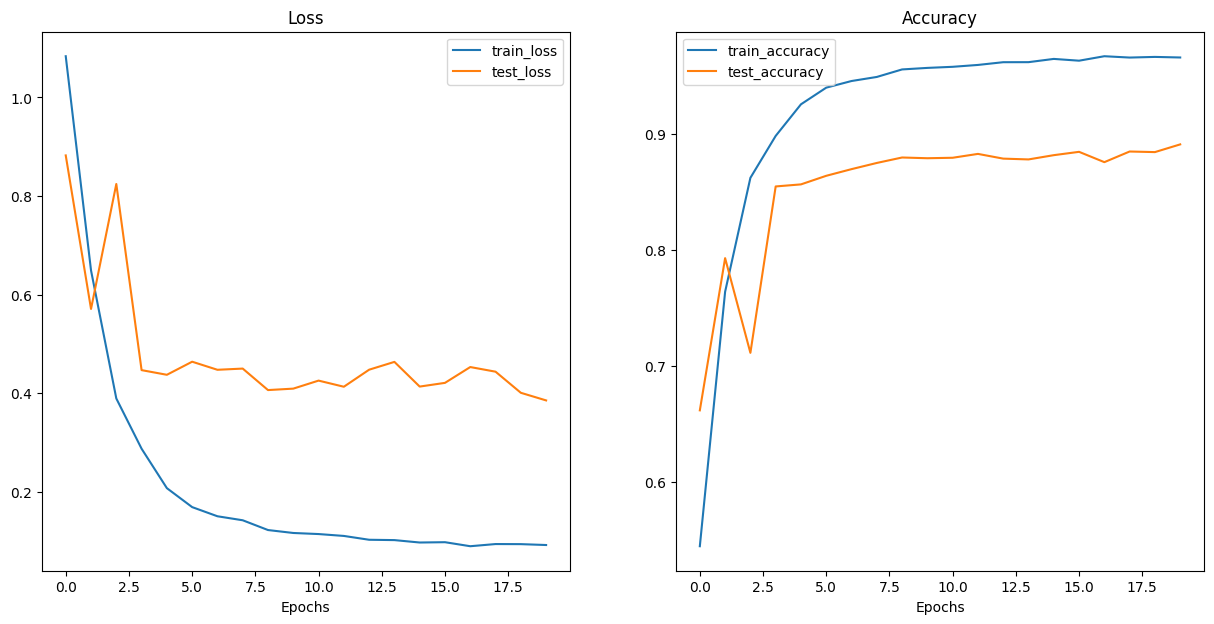

In [206]:
plot_loss_curves(model_results)

In [217]:
import torch

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_dataloader_custom :
        # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)              # shape: (batch_size, num_classes)
        preds = torch.argmax(outputs, dim=1)  # predicted class index
        probs = torch.softmax(outputs, dim=1)
        
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

In [219]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)


              precision    recall  f1-score   support

  Irrelevant       0.83      0.88      0.86      2949
    Negative       0.91      0.89      0.90      5255
     Neutral       0.90      0.86      0.88      4305
    Positive       0.86      0.89      0.87      4837

    accuracy                           0.88     17346
   macro avg       0.88      0.88      0.88     17346
weighted avg       0.88      0.88      0.88     17346



In [214]:

from sklearn.preprocessing import label_binarize


y_true = np.array(y_true)
y_scores = np.array(y_prob)

num_classes = 4
y_true_bin = label_binarize(y_true, classes=range(num_classes))

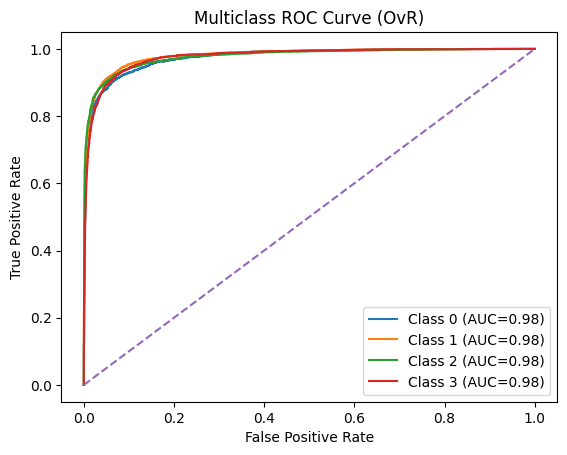

In [215]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OvR)")
plt.legend()
plt.show()
